## Random Forest - Intro and Regression

Random Forests are powerful machine learning algorithms used for supervised classification and regression. Random forests works by averaging the predictions of the multiple and randomized decision trees. Decision trees tends to overfit and so by combining multiple decision trees, the effect of overfitting can be minimized.

Random Forests are type of ensemble models. More about ensembles models in the next notebook.

Different to other learning algorithms, random forests provide a way to find the importance of each feature and this is implemented in Sklearn.

### Random Forests for Regression

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.datasets import fetch_openml

machine_cpu= fetch_openml(name='machine_cpu',version=1)

In [5]:
type(machine_cpu)

sklearn.utils._bunch.Bunch

In [6]:
machine_cpu.details

{'id': '230',
 'name': 'machine_cpu',
 'version': '1',
 'description_version': '1',
 'format': 'ARFF',
 'contributor': 'L. Torgo',
 'upload_date': '2014-04-23T13:20:36',
 'language': 'English',
 'licence': 'Public',
 'url': 'https://api.openml.org/data/v1/download/3667/machine_cpu.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0230/dataset_230.pq',
 'file_id': '3667',
 'default_target_attribute': 'class',
 'version_label': '1',
 'citation': 'https://archive.ics.uci.edu/ml/citation_policy.html',
 'tag': ['Computing', 'Data Analysis', 'OpenML-Reg19'],
 'visibility': 'public',
 'original_data_url': 'http://www.ics.uci.edu/~mlearn/MLSummary.html',
 'minio_url': 'https://data.openml.org/datasets/0000/0230/dataset_230.pq',
 'status': 'active',
 'processing_date': '2020-11-20 19:15:43',
 'md5_checksum': 'e26d62e83069b74dff6cf492e06868a0'}

In [7]:
machine_cpu.frame

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,class
0,125,256,6000,256,16,128,198
1,29,8000,32000,32,8,32,269
2,29,8000,32000,32,8,32,220
3,29,8000,32000,32,8,32,172
4,29,8000,16000,32,8,16,132
...,...,...,...,...,...,...,...
204,124,1000,8000,0,1,8,42
205,98,1000,8000,32,2,8,46
206,125,2000,8000,0,2,14,52
207,480,512,8000,32,0,0,67


In [8]:
machine_cpu.data.shape

(209, 6)

In [9]:
print(machine_cpu.DESCR)

**Author**:   
**Source**: Unknown -   
**Please cite**:   

The problem concerns Relative CPU Performance Data. More information can be obtained in the UCI Machine
 Learning repository (http://www.ics.uci.edu/~mlearn/MLSummary.html).
 The used attributes are :
 MYCT: machine cycle time in nanoseconds (integer)
 MMIN: minimum main memory in kilobytes (integer)
 MMAX: maximum main memory in kilobytes (integer)
 CACH: cache memory in kilobytes (integer)
 CHMIN: minimum channels in units (integer)
 CHMAX: maximum channels in units (integer)
 PRP: published relative performance (integer) (target variable)
 
 Original source: UCI machine learning repository. 
 Source: collection of regression datasets by Luis Torgo (ltorgo@ncc.up.pt) at
 http://www.ncc.up.pt/~ltorgo/Regression/DataSets.html
 Characteristics: 209 cases; 6 continuous variables

Downloaded from openml.org.


In [10]:
machine_cpu.feature_names , machine_cpu.target_names

(['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX'], ['class'])

In [11]:
machine_data=machine_cpu.frame
type(machine_data)

pandas.core.frame.DataFrame

### EDA

In [12]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(machine_data, test_size=0.2, random_state=20)

print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 167 
The size of testing data is: 42


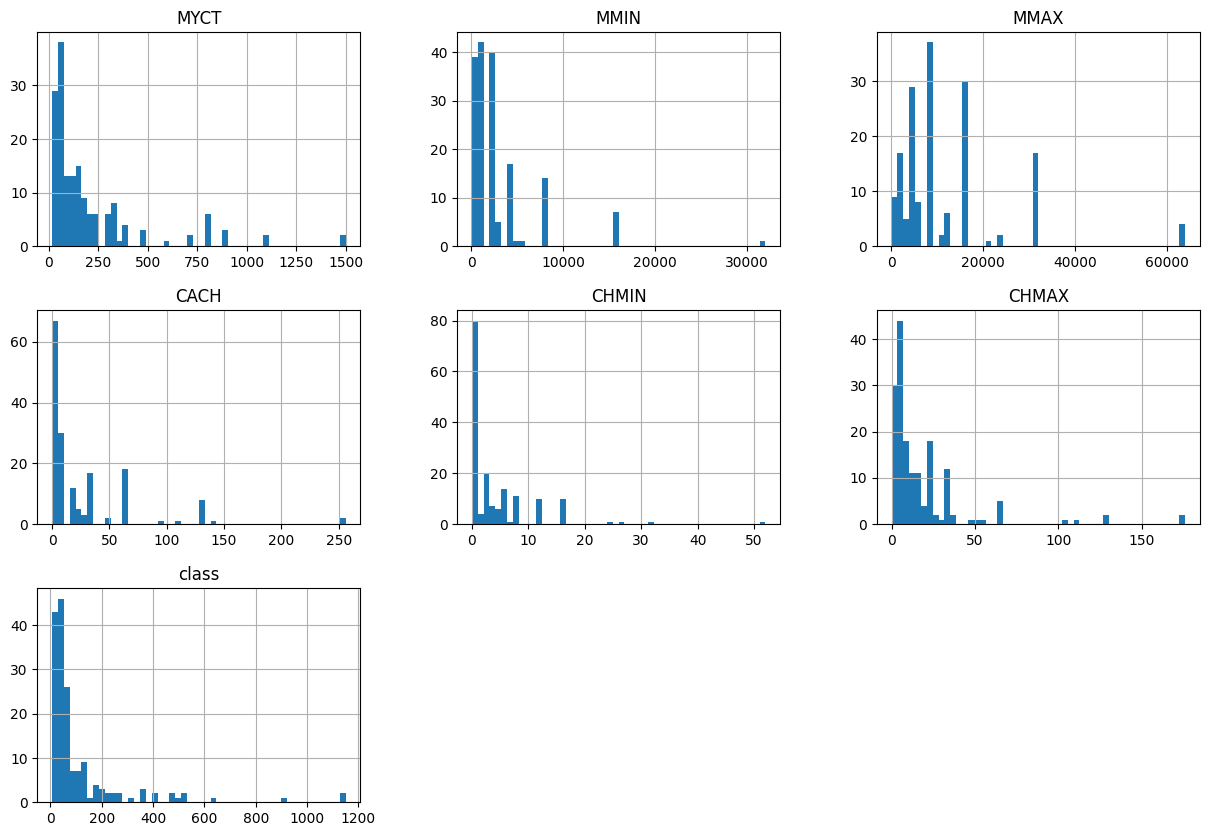

In [13]:
train_data.hist(bins=50, figsize=(15,10))
plt.show()

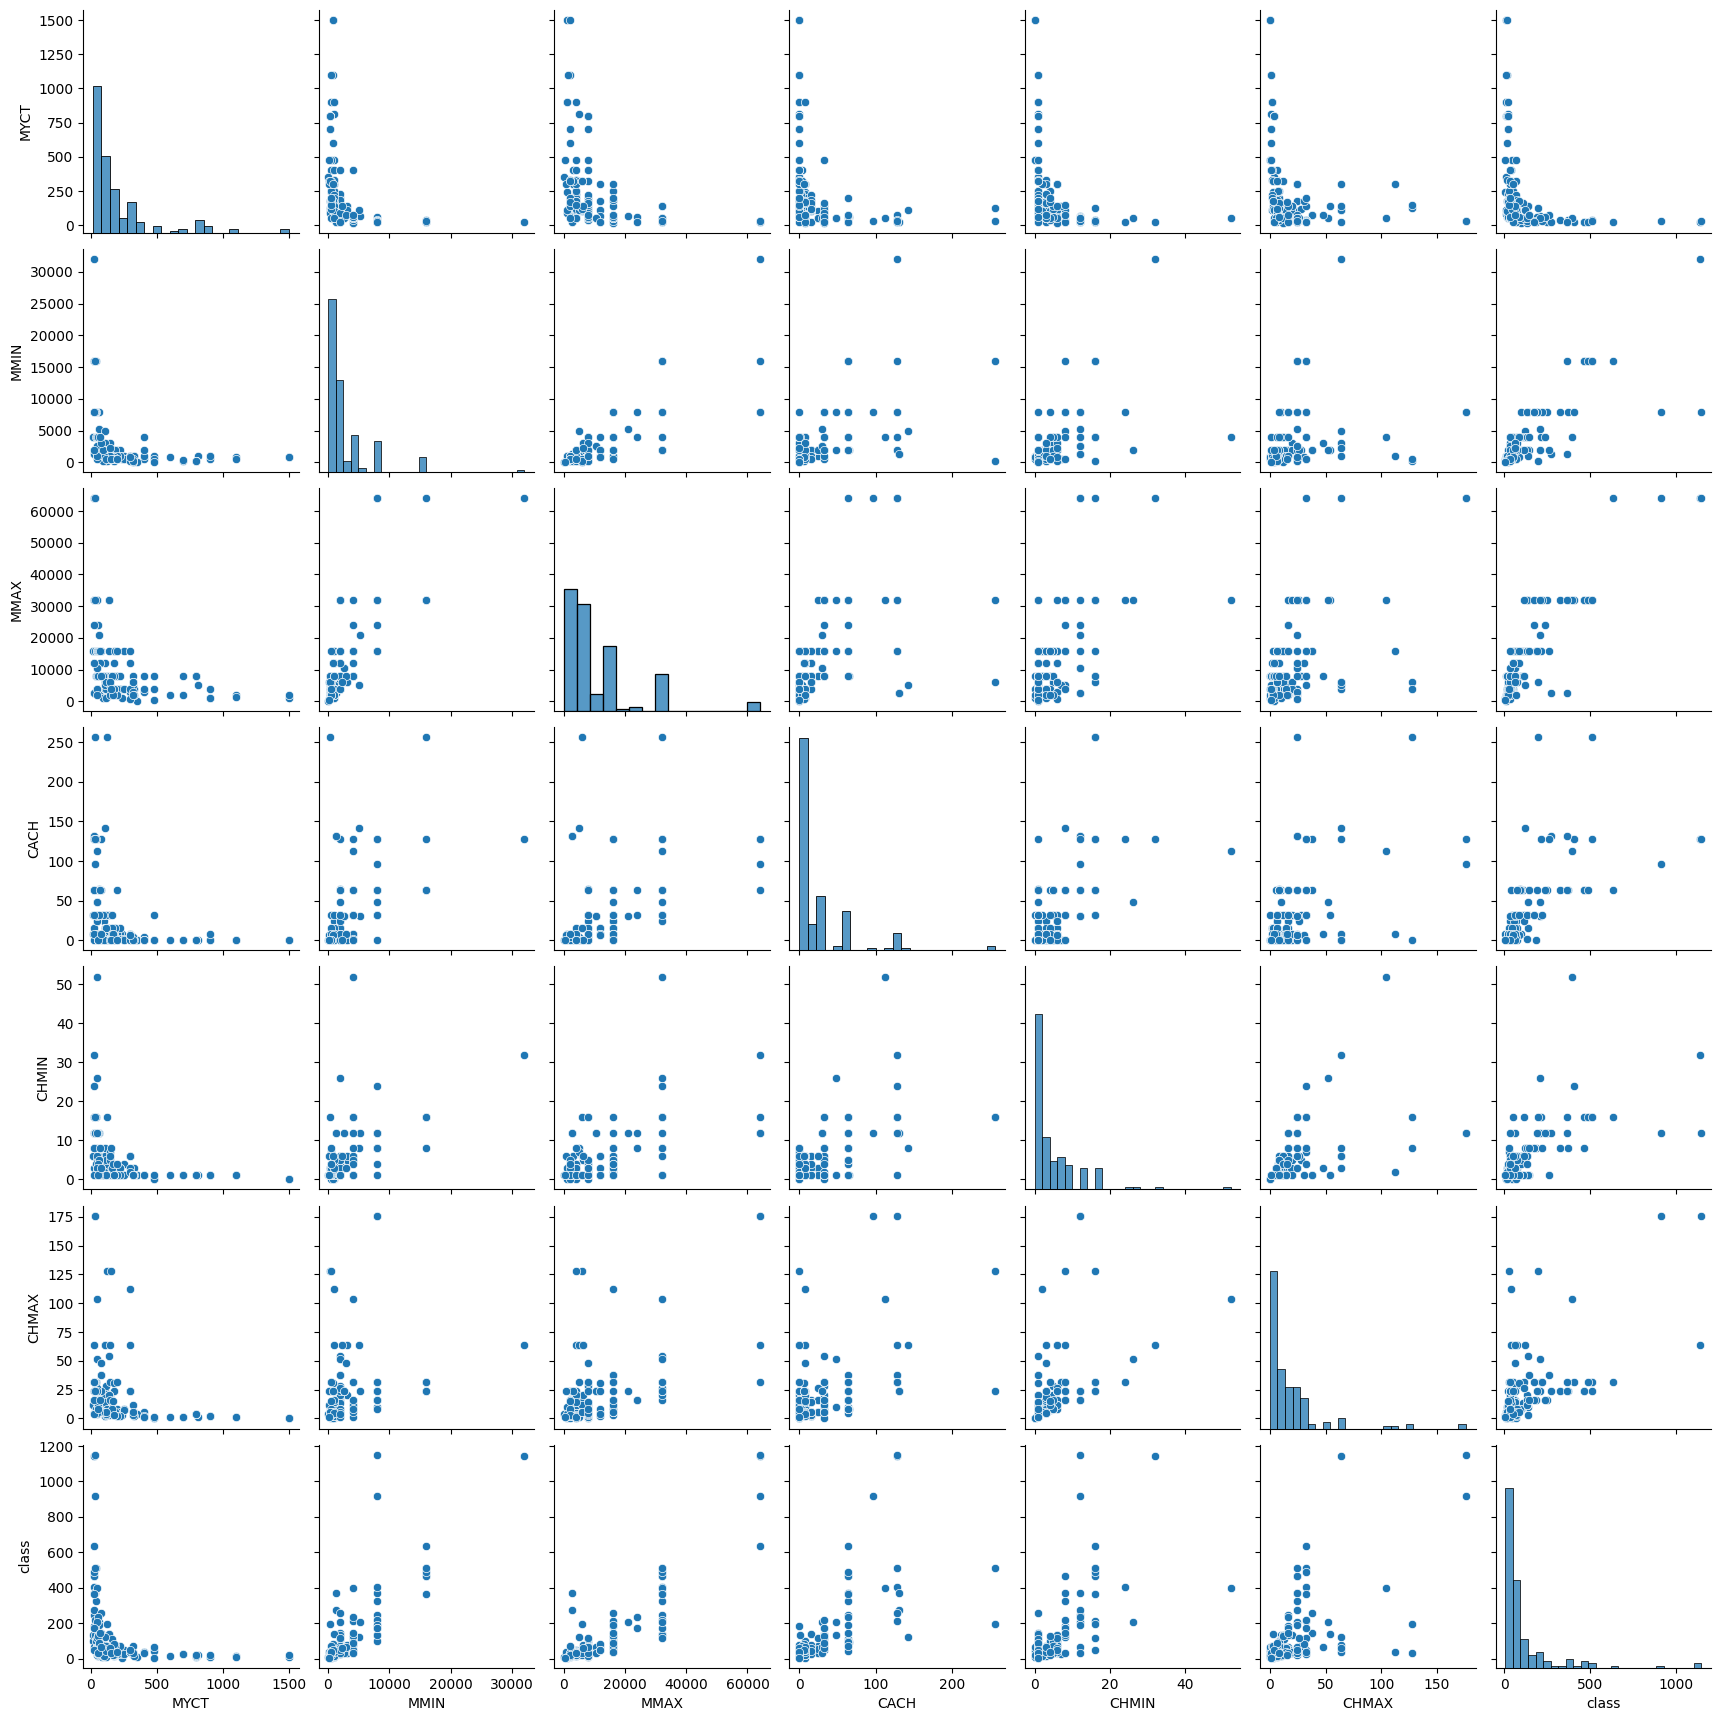

In [14]:
sns.pairplot(train_data)

In [15]:
train_data.describe()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,class
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,207.958084,2900.826347,11761.161677,26.071856,4.760479,18.616766,109.185629
std,266.772823,4165.950964,12108.332354,42.410014,6.487439,27.489919,174.061117
min,17.000000,64.000000,64.000000,0.000000,0.000000,0.000000,6.000000
25%,50.000000,768.000000,4000.000000,0.000000,1.000000,5.000000,27.500000
50%,110.000000,2000.000000,8000.000000,8.000000,2.000000,8.000000,50.000000
75%,232.500000,3100.000000,16000.000000,32.000000,6.000000,24.000000,110.000000
max,1500.000000,32000.000000,64000.000000,256.000000,52.000000,176.000000,1150.000000


In [16]:
train_data.isnull().sum()

MYCT     0
MMIN     0
MMAX     0
CACH     0
CHMIN    0
CHMAX    0
class    0
dtype: int64

In [18]:
corr=train_data.corr()
corr['class']

MYCT    -0.301805
MMIN     0.797751
MMAX     0.869077
CACH     0.671581
CHMIN    0.648653
CHMAX    0.606557
class    1.000000
Name: class, dtype: float64

<Axes: >

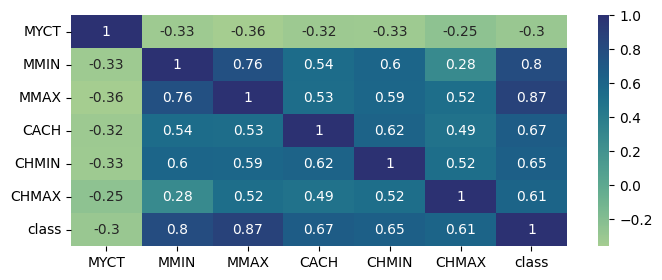

In [21]:
plt.figure(figsize=(8,3))
sns.heatmap(corr,annot=True, cmap='crest')

### Data Preprocessing

In [24]:
X_train=train_data.drop('class',axis=1)
y_train=train_data['class']

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scale_pipe=Pipeline([
    ('scaler',StandardScaler())
])

X_train_scaled=scale_pipe.fit_transform(X_train)

### Training Random Forest Regressor

In [32]:
from sklearn.ensemble import RandomForestRegressor
RandomForestRegressor().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [ ]:
forest_reg = RandomForestRegressor(min_samples_split=2,bootstrap=False, random_state=42,n_jobs=-1)

forest_reg.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


#### Here's a breakdown of each parameter: 
`min_samples_split=2`:\
This parameter specifies the minimum number of samples required to split an internal node. A node will only be split if it contains at least two samples. This helps to prevent the trees from growing too deep and potentially overfitting the training data.\
`bootstrap=False`:\
In a standard Random Forest, bootstrapping (sampling with replacement) is used to create different training subsets for each individual decision tree. Setting bootstrap=False means that the entire dataset will be used to train each tree, without replacement. This can be useful in certain scenarios but might increase the correlation between individual trees compared to when bootstrapping is enabled.\
`random_state=42`:\
This parameter sets the random seed for reproducibility. When random_state is set to a specific integer (like 42), the random processes involved in building the forest (e.g., feature sampling, data splitting) will produce the same results every time the code is run. This ensures that the model's performance is consistent across different runs.\
`n_jobs=-1`:\
This parameter controls the number of CPU cores or threads to use for parallel processing during model training. Setting n_jobs=-1 instructs the algorithm to use all available CPU cores, which can significantly speed up the training process for larger datasets or more complex models.

### Evaluating Random Forests Regressor

In [34]:
from sklearn.metrics import mean_squared_error

def predict(input_data,model,labels):
    preds=model.predict(input_data)
    mse=mean_squared_error(labels,preds)
    rmse=np.sqrt(mse)
    return rmse

In [35]:
predict(X_train_scaled,forest_reg,y_train)

np.float64(9.724590719956222)

### __Improving Random Forests__

In [36]:
from sklearn.model_selection import GridSearchCV

params_grid={
    'n_estimators':[100,200,300,400,500],
    'max_leaf_nodes':list(range(0,50))}

grid_search=GridSearchCV(RandomForestRegressor(min_samples_split=2,bootstrap=False,random_state=42), params_grid, verbose=1, cv=5)
grid_search.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_leaf_nodes': [0, 1, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [37]:
grid_search.best_params_

{'max_leaf_nodes': 46, 'n_estimators': 200}

In [38]:
forest_best=grid_search.best_estimator_

In [39]:
predict(X_train_scaled,forest_best,y_train)

np.float64(12.217411163164076)

Surprisingly, by searching model hyperparameters, the model did not improve. Can you guess why? I have observed many things while running Grid Search and reading about the [random forests](https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees). If you can't get good results, set the `bootstrap` to False. It is true by default, and that means that you are training on samples of the training set instead of the whole training set. Try going back to the orginal model and change it to True and note how the prediction changes. Also learn more about the other hyperparameters.

### Feature Importance

Different to other machine learning models, random forests can show how each feature contributed to the model generalization. Let's find it. The results are values between 0 and 1. The closer to 1, the good the feature was to the model.

In [41]:
feat_import = forest_best.feature_importances_

feat_dict ={
    
    'Features': X_train.columns,
    'Feature Importance': feat_import
}

pd.DataFrame(feat_dict)

,Features,Feature Importance
0,MYCT,0.002990
1,MMIN,0.005777
2,MMAX,0.835472
3,CACH,0.117459
4,CHMIN,0.007567
5,CHMAX,0.030735


As you can see above, the most 2 features which contributed to the prediction of the relative performance of the CPU are `MMAX` which is the Maximum Main Memory in Kilobytes and `CACH` (cache memory).

It makes sense that the model was able to find that out. Main memory (RAM, Read Only Memory) and cache memory (which stores frequently used information thus facilitating faster processing and quick retrieval of information) are the two most factors of the CPU performance and if you are going to buy a new computer, you want to have high RAM and cache memory in order to have a powerful machine that can process/compute and retrieve things faster.

### Evaluating the Model on the Test Set

Let us evaluate the model on the test set. But I will first run the pipeline on the test data. Note that we only transform (not fit_transform).

In [42]:
X_test=test_data.drop('class',axis=1)
y_test=test_data['class']

test_scaled = scale_pipe.transform(X_test)

In [43]:
predict(test_scaled,forest_best,y_test)

np.float64(41.258341325352305)

The results on the test set is not appealing, and it is a sign that the model is still overfitting the data(it is doing well on the training set and poor on the new data). One way to improve the model can be to regularize the model by searching more best hyperparameters and increasing the data and data quality. The later is what can improve the model in many scenarios.